In [5]:
%pip install pandas scikit-learn catboost xgboost seaborn matplotlib joblib sentence-transformers faiss-cpu torch

Note: you may need to restart the kernel to use updated packages.


In [6]:
import pandas as pd
import numpy as np
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics.pairwise import cosine_similarity
from catboost import CatBoostRegressor, Pool
from sentence_transformers import SentenceTransformer
import matplotlib.pyplot as plt
import pickle
import faiss
import torch
import warnings
import os
RANDOM_STATE = 42
warnings.filterwarnings("ignore", category=UserWarning, module="huggingface_hub.utils._auth")

In [7]:
# Load from file
loaded_model = CatBoostRegressor()
loaded_model.load_model('catboost_info.cbm')

In [8]:
df = pd.read_csv("car_prices_extended_eda.csv", parse_dates=False)
df.columns

Index(['year', 'make', 'model', 'trim', 'body', 'transmission', 'vin', 'state',
       'condition', 'odometer', 'color', 'interior', 'seller', 'mmr',
       'sellingprice', 'saledate', 'price_diff', 'car_age', 'mileage_per_year',
       'sale_year', 'sale_month', 'sale_day', 'seller_category',
       'condition_category', 'sale_day_of_week', 'sale_day_name', 'sale_hour',
       'is_weekend', 'sale_month_name', 'price_gap_pct', 'gap_category',
       'is_luxury'],
      dtype='object')

In [9]:
drop_cols = ["vin", "saledate", "price_diff"]
df = df.drop(columns=drop_cols)

In [10]:
# Log-skewed cols (as before)
skewed_cols = ["odometer", "car_age"]
df[skewed_cols] = np.log1p(df[skewed_cols])

In [11]:
# X and y
y = df["sellingprice"]
X = df.drop(columns=["sellingprice"])

In [12]:
# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
y_train_pred = loaded_model.predict(X_train)
y_test_pred = loaded_model.predict(X_test)

# Restore original continuous y_train and y_test from the global 'y' using the split indices
y_train_continuous = y.loc[X_train.index]
y_test_continuous = y.loc[X_test.index]

# Metrics
train_mae = mean_absolute_error(y_train_continuous, y_train_pred)
test_mae = mean_absolute_error(y_test_continuous, y_test_pred)
train_rmse = np.sqrt(mean_squared_error(y_train_continuous, y_train_pred))
test_rmse = np.sqrt(mean_squared_error(y_test_continuous, y_test_pred))

print(f"Train MAE: ${train_mae:.0f} | Test MAE: ${test_mae:.0f} | Gap: {((train_mae - test_mae) / test_mae * 100):+.1f}%")
print(f"Train RMSE: ${train_rmse:.0f} | Test RMSE: ${test_rmse:.0f} | Gap: {((train_rmse - test_rmse) / test_rmse * 100):+.1f}%")

# Threshold: If test/train ratio <0.85 (test 15% worse), overfitting likely
if test_rmse / train_rmse < 0.85:
    print("⚠️ Potential Overfitting: Test underperforms train significantly.")
else:
    print("✅ Good Fit: Metrics are comparable.")

Train MAE: $148 | Test MAE: $156 | Gap: -5.0%
Train RMSE: $694 | Test RMSE: $830 | Gap: -16.4%
✅ Good Fit: Metrics are comparable.


Confusion Matrix:
 [[ 5760   274     0     0     0     0     0     0     0     0]
 [   92 10178   289     0     0     0     0     0     0     0]
 [    0    78  6125   345     0     0     0     0     0     0]
 [    0     0    82  7318   422     0     0     0     0     0]
 [    0     0     1    95 14893   566     0     0     0     0]
 [    0     0     0     0   108  9620   403     1     0     0]
 [    0     0     0     0     1    98  7212   305     1     0]
 [    0     0     0     0     0     0   105  5893   375     0]
 [    0     0     0     0     0     0     0    74  4702   291]
 [    0     0     0     0     0     0     0     0    59 18699]]

Classification Report:
               precision    recall  f1-score   support

 12001-14000       0.94      0.95      0.94     10132
 14001-16000       0.93      0.95      0.94      7617
 16001-18000       0.94      0.92      0.93      6373
 18001-20000       0.92      0.93      0.92      5067
   2000-5000       0.97      0.96      0.97     10559


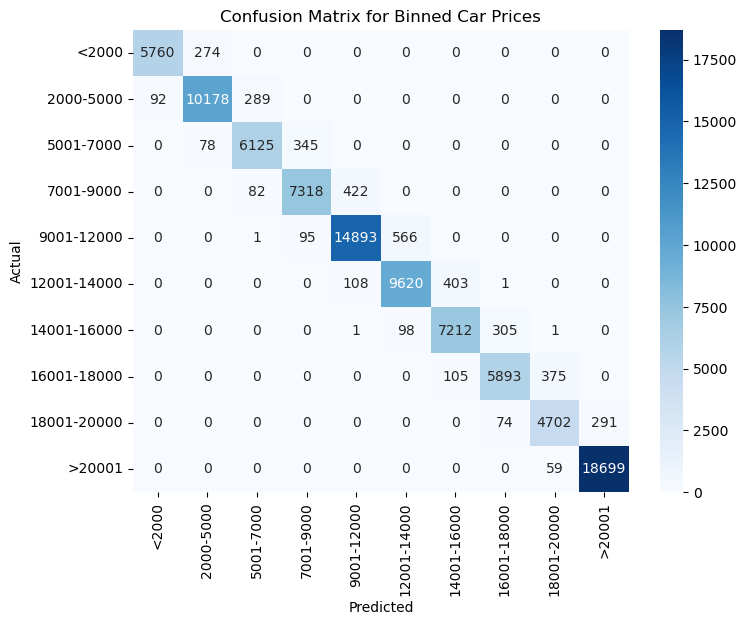

In [14]:
# Bin prices
bins = [0, 2000, 5000, 7000,9000,12000,14000,16000,18000,20000,  np.inf]  # Low (<15k), Medium (15-25k), High (>25k)
labels = ['<2000','2000-5000', '5001-7000', '7001-9000', '9001-12000','12001-14000', '14001-16000', '16001-18000', '18001-20000', '>20001']

# Predict
y_pred_continuous = loaded_model.predict(X_test)
y_pred_binned = pd.cut(y_pred_continuous, bins=bins, labels=labels, include_lowest=True)

# Bin y_test for comparison
y_test_binned = pd.cut(y_test_continuous, bins=bins, labels=labels, include_lowest=True)

# Confusion Matrix
cm = confusion_matrix(y_test_binned, y_pred_binned, labels=labels)
print("Confusion Matrix:\n", cm)

# Report
print("\nClassification Report:\n", classification_report(y_test_binned, y_pred_binned))

# Plot (as in notebook)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.title('Confusion Matrix for Binned Car Prices')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()